In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load EEG Dataset

In [198]:
data = np.load("../eeg_processed/eeg_data_ICA.npz")
X_main, y = data['X'], data['y']
print(f"X (n_trails, n_channels, n_samples) : {X_main.shape}")
print(f"y (n_trails, ) : {y.shape}")

X (n_trails, n_channels, n_samples) : (1799, 16, 500)
y (n_trails, ) : (1799,)


# Features 

## 1. Extract Time Related Features

In [199]:
from scipy.stats import (skew, 
                        kurtosis)

Skewness

- Normally skewed distribution - if the skewness values are within -0.5 to 0.5
- Moderate skewed distribution - if the skewness values are within -0.5 to -1 for negatively moderate skewed and 0.5 to 1 for postively moderate skewed

- Highly skewed distribution - if the skewness values are outside of -1 and 1 


Kurtosis - statistical measure that describes the heaviness of a distribution's tails and the concentration of data around the mean

- Normal distribution has a kurtosis of 3

- Leptokurtic - with a kurtosis value greater than 3 - this indicates heavier tails and a more peaked center

- Platykurtic - with a kurtosis value lesser than 3 - this indicates lighter tails and a flatter center

In [200]:
def extract_time_features(X):
    """Extract time-domain features"""
    n_trials, n_channels, n_samples = X.shape
    
    features = []
    for trial in range(n_trials):
        trial_features = []
        
        for ch in range(n_channels):
            signal = X[trial, ch, :]
            
            # Statistical features
            trial_features.extend([
                np.mean(signal),          # Mean
                np.std(signal),           # Standard deviation
                np.var(signal),           # Variance
                skew(signal),             # Skewness
                kurtosis(signal),         # Kurtosis
                np.max(signal),           # Maximum
                np.min(signal),           # Minimum
                np.ptp(signal),           # Peak-to-peak
                np.median(signal),        # Median
                np.mean(np.abs(signal)),  # Mean absolute value
            ])
            
            # Zero crossing rate
            zero_crossings = np.sum(np.diff(np.sign(signal)) != 0)
            trial_features.append(zero_crossings)
            
            # Root mean square
            rms = np.sqrt(np.mean(signal**2))
            trial_features.append(rms)
            
        features.append(trial_features)
        
    return np.array(features)

In [201]:
try:
    X_time_features = extract_time_features(X_main)
    assert(X_time_features.shape[0] == X_main.shape[0])
    print("---- Success - Time Related Features ----")
except:
    print("---- Failure - Time Related Features ----")

---- Success - Time Related Features ----


In [202]:
col_names= ["mean", "std", "variance", "skeeness","kurtosis", "maximum", 
        "minimum", "peak-to-peak", "median", "mean_absolute_value","zero_crossing_rate","root_mean_square"]

timefeature_col_names = [f"electrode_{i}_{col_name}" for i in range(16) for col_name in col_names]

X_time_features = pd.DataFrame(X_time_features)
X_time_features.columns = timefeature_col_names

In [203]:
def plot_time_series(X_main, trail, electrode):
    plt.figure(figsize = (15, 10))
    plt.plot(X_main[trail, 1, :],  label = "EEG Signal")
    plt.axhline(y = np.mean(X_main[trail, electrode, :]), 
                color = 'r', 
                linestyle = '--', 
                label = f"Mean Line - {np.round(np.mean(X_main[trail, electrode, :]), 2)}")
    plt.axhline(y = np.median(X_main[trail, electrode, :]), 
                color = 'g', 
                linestyle = '--', 
                label = f"Median Line - {np.round(np.median(X_main[trail, electrode, :]), 2)}")
    plt.axhline(y = np.max(X_main[trail, electrode, :]), 
                linestyle = '--', 
                label = f"Max Line - {np.round(np.max(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.min(X_main[trail, electrode, :]), 
                color = 'y',
                linestyle = '--', 
                label = f"Min Line - {np.round(np.min(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.mean(X_main[trail, electrode, :]) + np.std(X_main[trail, electrode, :]), 
                color = 'pink',
                linestyle = '--', 
                label = f"Standard Deviation (Upper) Line - {np.round(np.mean(X_main[trail, electrode, :]) + np.std(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.mean(X_main[trail, electrode, :]) - np.std(X_main[trail, electrode, :]), 
                color = 'pink',
                linestyle = '--', 
                label = f"Standard Deviation (lower) Line - {np.round(np.mean(X_main[trail, electrode, :]) - np.std(X_main[trail, electrode, :]), 2)}")


    plt.title(f"Skewness - {skew(X_main[trail, electrode, :])}, Kurtosis - {kurtosis(X_main[trail, electrode, :])}, Trail - {trail}, Electrode - {electrode}")

    plt.legend()
    plt.show()

In [231]:
X_time_features

,electrode_0_mean,electrode_0_std,electrode_0_variance,electrode_0_skeeness,electrode_0_kurtosis,electrode_0_maximum,electrode_0_minimum,electrode_0_peak-to-peak,electrode_0_median,electrode_0_mean_absolute_value,...,electrode_15_variance,electrode_15_skeeness,electrode_15_kurtosis,electrode_15_maximum,electrode_15_minimum,electrode_15_peak-to-peak,electrode_15_median,electrode_15_mean_absolute_value,electrode_15_zero_crossing_rate,electrode_15_root_mean_square
0,-0.108985,5.311873,28.216000,0.180026,0.321781,18.712052,-15.693551,34.405602,-0.237947,4.146774,...,904.245842,-1.924888,48.982824,261.363293,-296.598637,557.961931,1.555820,12.598154,97.0,30.070685
1,0.010111,9.461448,89.519002,-0.464545,13.334869,52.061413,-58.849037,110.910450,-0.324319,5.605248,...,104.508588,-0.782402,4.880458,40.781090,-62.380629,103.161719,1.309865,7.286213,104.0,10.222954
2,-0.001309,6.478703,41.973593,1.352291,17.610001,60.690456,-33.351484,94.041940,-0.279226,4.380301,...,149.427636,-0.570832,1.687644,38.619068,-39.942786,78.561854,0.672039,8.754124,92.0,12.226187
3,-0.007816,5.290801,27.992575,0.171111,0.269152,18.677672,-15.170780,33.848452,-0.026016,4.133685,...,350.426957,-0.566488,3.115077,62.575022,-88.727323,151.302345,1.812321,12.776454,78.0,18.720626
4,0.035569,11.333280,128.443237,-0.992139,15.432995,58.541090,-79.629694,138.170784,-0.315633,6.577718,...,1650.460648,-0.033929,9.444965,287.695069,-178.944770,466.639839,2.322068,24.143754,82.0,40.625863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1794,-0.015436,11.916566,142.004552,-0.254835,7.297965,48.841329,-73.101794,121.943123,-0.510849,7.555459,...,72.636946,-0.298189,1.018207,28.124861,-28.191741,56.316602,0.530749,6.414485,121.0,8.522733
1795,0.002563,5.226956,27.321070,-0.011549,0.002729,14.425063,-16.974515,31.399578,-0.336738,4.144499,...,28.998359,-0.013201,-0.068138,16.035890,-16.598641,32.634532,0.046811,4.334763,128.0,5.385027
1796,-0.137255,8.755250,76.654407,1.011115,7.206669,47.708618,-32.222161,79.930779,-0.617118,5.597995,...,44.985112,-0.251186,-0.016179,17.547718,-20.762344,38.310062,0.504595,5.362823,123.0,6.707121
1797,0.272293,10.854545,117.821148,6.609323,101.148287,138.810240,-80.739266,219.549506,0.037948,4.638254,...,62.324099,-0.739071,2.725330,21.572805,-44.908284,66.481089,0.258055,5.984345,116.0,7.894884


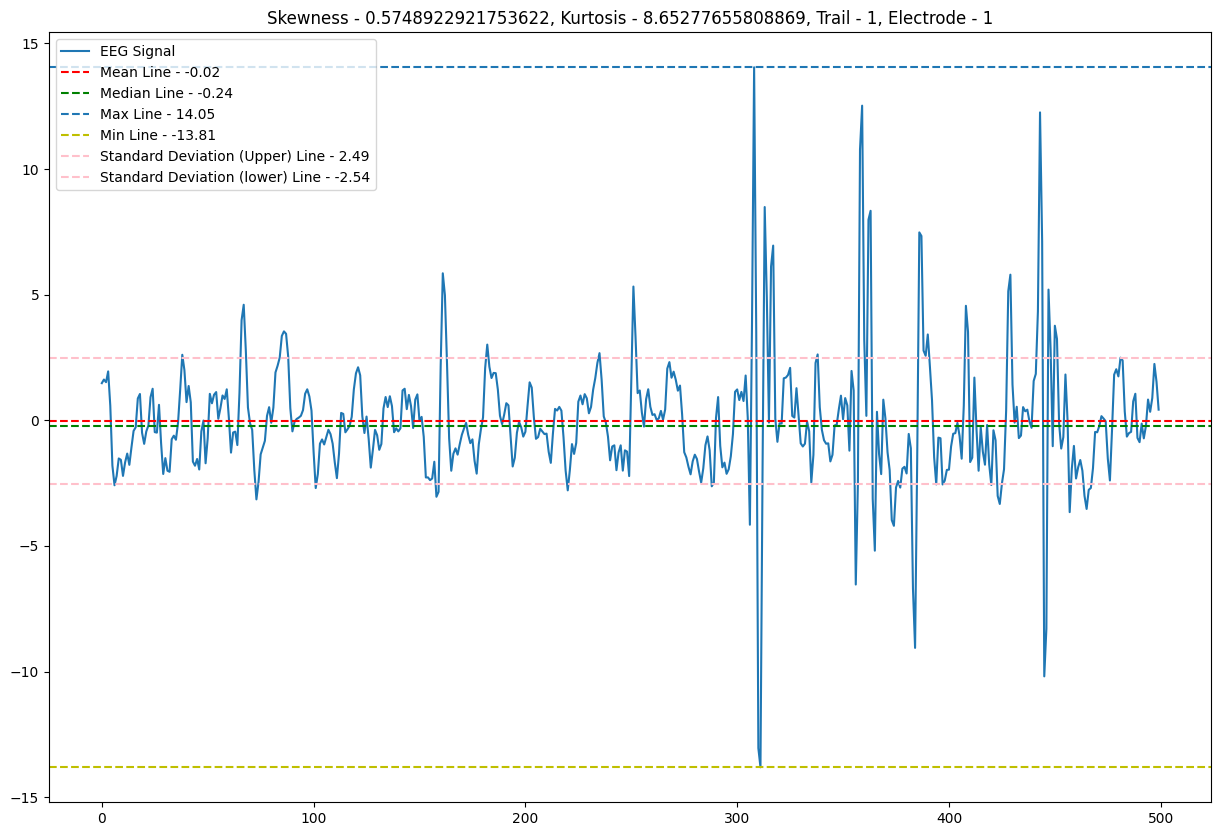

In [204]:
plot_time_series(X_main, trail = 1, electrode = 1)

# 2 . Frequency Related Features

In [205]:
from scipy.signal import welch

In [206]:
def extract_frequency_features(X, sfreq, freq_bands):
        """Extract frequency-domain features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):

            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Power spectral density
                freqs, psd = welch(signal, fs=sfreq, nperseg=min(256, n_samples//4))
                
                # Band power features
                for band_name, (low, high) in freq_bands.items():
                    band_mask = (freqs >= low) & (freqs <= high)
                    band_power = np.sum(psd[band_mask])
                    trial_features.append(band_power)
                
                # Spectral features
                total_power = np.sum(psd)
                spectral_centroid = np.sum(freqs * psd) / total_power
                spectral_spread = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * psd) / total_power)
                spectral_entropy = -np.sum((psd/total_power) * np.log2(psd/total_power + 1e-12))
                
                trial_features.extend([
                    total_power,
                    spectral_centroid,
                    spectral_spread,
                    spectral_entropy
                ])
                
                # Peak frequency
                peak_freq = freqs[np.argmax(psd)]
                trial_features.append(peak_freq)
                
            features.append(trial_features)
            
        return np.array(features)

In [207]:
freq_bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13),
 'beta': (13, 30), 'gamma': (30, 50)}
sfreq = 250


X_frequence_features = extract_frequency_features(X = X_main, 
                                                  sfreq = 250, 
                                                  freq_bands= freq_bands)




In [208]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_frequence_features)
X_frequence_features_norm = sc.transform(X_frequence_features)

In [209]:
freq_features_names = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'total_power', 'centroid', 'spread', 'entropy', 'peak_freq']
freq_col_names = [f"electrode_{i}_{col_name}" for i in range(16) for col_name in freq_features_names]

X_frequence_features_norm = pd.DataFrame(X_frequence_features_norm)
X_frequence_features_norm.columns = freq_col_names

In [230]:
X_frequence_features_norm

,electrode_0_delta,electrode_0_theta,electrode_0_alpha,electrode_0_beta,electrode_0_gamma,electrode_0_total_power,electrode_0_centroid,electrode_0_spread,electrode_0_entropy,electrode_0_peak_freq,...,electrode_15_delta,electrode_15_theta,electrode_15_alpha,electrode_15_beta,electrode_15_gamma,electrode_15_total_power,electrode_15_centroid,electrode_15_spread,electrode_15_entropy,electrode_15_peak_freq
0,-0.066573,-0.060730,-0.065054,-0.061329,-0.051224,-0.064260,-0.707200,-0.145112,0.028185,-0.246432,...,-0.037008,-0.014683,-0.001866,0.030519,0.020040,0.003064,-1.091405,-2.238516,-0.798657,-0.581507
1,-0.070237,-0.062725,-0.062418,-0.062392,-0.040736,-0.041587,3.300263,0.533023,-0.230308,4.043877,...,-0.051092,-0.041193,-0.035221,-0.033585,-0.028667,-0.033812,-1.043147,0.070863,-0.530429,-0.581507
2,-0.069411,-0.061559,-0.061409,-0.059758,-0.044130,-0.059506,0.638419,1.205610,0.640347,-0.766470,...,-0.043528,-0.035546,-0.032871,-0.031858,-0.028413,-0.032012,-1.985522,-1.802434,-1.898118,-0.765977
3,-0.065204,-0.060842,-0.063559,-0.066702,-0.049401,-0.064853,-0.842620,-0.179754,0.114378,-0.636461,...,-0.013186,-0.014582,-0.018212,-0.027550,-0.027443,-0.023940,-2.503650,-3.145246,-3.048255,-0.765977
4,-0.060941,-0.055445,-0.056011,-0.049833,-0.022250,-0.045183,0.873345,0.883057,0.853395,-0.766470,...,0.092661,0.030648,0.018948,0.033347,-0.002238,0.016696,-1.772236,-1.746334,-1.344040,-0.581507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1794,0.025591,0.010837,-0.015476,-0.046456,-0.046844,-0.029929,-2.582686,-1.997472,-3.574999,-0.896479,...,-0.050936,-0.040768,-0.035874,-0.032956,-0.028878,-0.033838,-1.173367,-0.373937,-0.599265,-0.950447
1795,-0.070380,-0.064109,-0.067039,-0.065998,-0.046107,-0.065030,0.394432,-0.178556,0.592633,1.313680,...,-0.054009,-0.043744,-0.037471,-0.034923,-0.029489,-0.035418,-0.167271,0.266572,0.464989,-0.581507
1796,0.009906,-0.035321,-0.058905,-0.064726,-0.051153,-0.053312,-2.655133,-1.372617,-3.269556,-1.026489,...,-0.053210,-0.043161,-0.036761,-0.034863,-0.029291,-0.034998,-0.516943,0.500689,0.083018,-0.581507
1797,-0.067161,-0.061000,-0.060644,-0.033751,0.013922,-0.032422,1.370236,0.049872,0.936648,0.923652,...,-0.052576,-0.041991,-0.036450,-0.033688,-0.028752,-0.034310,-0.512095,0.582049,0.031136,-0.765977


# 3. Time-Frequency Features

Using the Hilbert Transform, you can track how the power (amplitude) of alpha waves (8–12 Hz) changes over time or see how their phase aligns with other brain rhythms.

Hilbert Transform = a way to get amplitude and phase information from a signal.

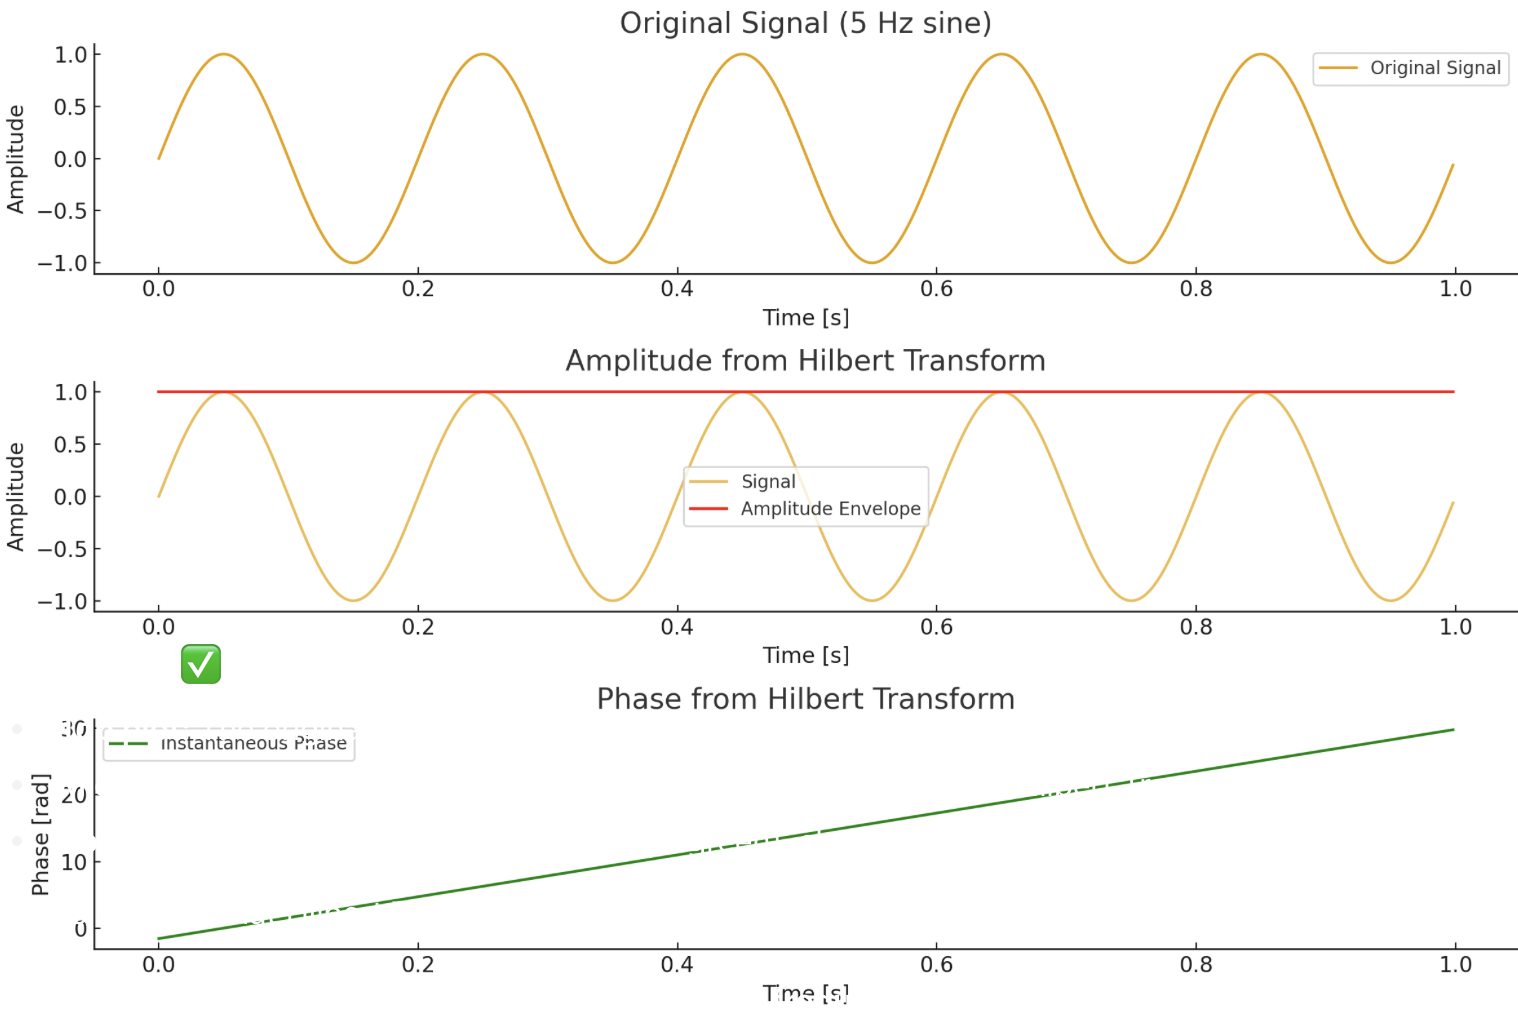

In [225]:
from scipy.signal import hilbert

In [226]:
def extract_joint_features( X):
        """Extract time-frequency joint features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):
            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Hilbert transform for instantaneous features
                analytic_signal = hilbert(signal)
                amplitude_envelope = np.abs(analytic_signal)
                instantaneous_phase = np.unwrap(np.angle(analytic_signal))
                instantaneous_freq = np.diff(instantaneous_phase) / (2.0 * np.pi) * sfreq
                
                # Amplitude envelope features
                trial_features.extend([
                    np.mean(amplitude_envelope),
                    np.std(amplitude_envelope),
                    np.max(amplitude_envelope),
                    skew(amplitude_envelope)
                ])
                
                # Instantaneous frequency features (handle edge cases)
                if len(instantaneous_freq) > 0:
                    trial_features.extend([
                        np.mean(instantaneous_freq),
                        np.std(instantaneous_freq),
                        np.median(instantaneous_freq)
                    ])
                else:
                    trial_features.extend([0, 0, 0])
                
                # Wavelet-based features (simplified)
                from scipy.signal import cwt, ricker
                scales = np.arange(1, 31)
                coefficients = cwt(signal, ricker, scales)
                
                # Energy in different scales
                for scale_group in [(1, 5), (6, 15), (16, 30)]:
                    scale_energy = np.sum(np.abs(coefficients[scale_group[0]:scale_group[1]])**2)
                    trial_features.append(scale_energy)
                
            features.append(trial_features)
            
        return np.array(features)
    

In [ ]:
extract_joint_features(X_main

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_2490/2470454870.py:39: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  coefficients = cwt(signal, ricker, scales)


array([[6.45883725e+00, 3.83760168e+00, 2.15326745e+01, ...,
        6.35553423e+06, 1.11649895e+07, 5.53187083e+06],
       [8.75288149e+00, 1.01205302e+01, 6.54880045e+01, ...,
        6.31375961e+05, 2.26635441e+06, 2.13663741e+06],
       [6.87717904e+00, 6.05405433e+00, 6.55951260e+01, ...,
        1.05165907e+06, 4.26812952e+06, 4.03687647e+06],
       ...,
       [8.72897790e+00, 8.78251172e+00, 4.88138613e+01, ...,
        2.54851056e+05, 8.11879321e+05, 8.41425232e+05],
       [7.31054882e+00, 1.35008241e+01, 1.81964359e+02, ...,
        3.49691731e+05, 1.36763109e+06, 8.92642499e+05],
       [8.10032647e+00, 4.42614360e+00, 2.74676870e+01, ...,
        2.35863468e+05, 4.33128370e+05, 3.38635732e+05]])